In [42]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from math import *

In [10]:
def removeDC(y): 
    M=y.max()
    m=y.min()
    mid=(M+m)/2
    return y-mid

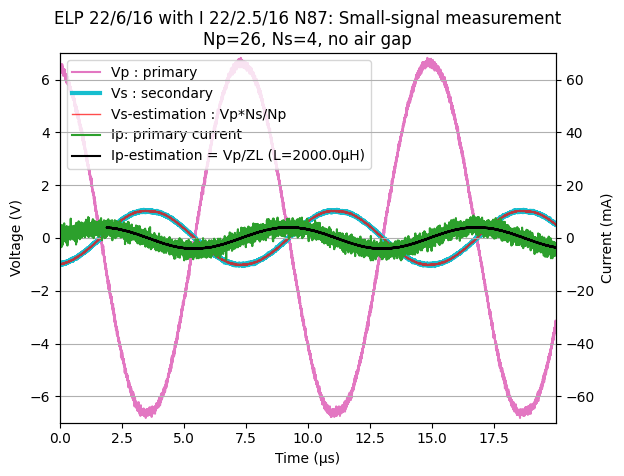

In [71]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("2025-12-21_15-43-53-910.csv")
Ts = df.Ts.values[0]
Vp = df.CH3.values
Vs = df.CH2.values
Ip = df.CH4.values

Vp=removeDC(Vp)
Vs=removeDC(Vs)
Ip=removeDC(Ip)
time = np.arange(0, len(Vp)*Ts, Ts)

fig, ax1 = plt.subplots()

ax1.plot(1e6*time, Vp, label="Vp : primary", c="C6")
ax1.plot(1e6*time, Vs, label="Vs : secondary", c="C9", linewidth=3)
ax1.plot(1e6*time, -Vp*4/26, label="Vs-estimation : Vp*Ns/Np", #linestyle='--', 
         alpha=0.7, color="r", linewidth=1)
ax1.set_xlabel("Time (µs)")
ax1.set_ylabel("Voltage (V)")
#ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(1e6*time, 1e3*Ip, color="C2", label="Ip: primary current")
L=2000e-6
F=132e3
Z = L*2*pi*F
Ip_cal = Vp/Z
T=1/F
phase_time=0.25* T # 90° is 25% of 360°

ax2.plot(1e6*(time+phase_time), 1e3*Ip_cal, color="k", label=f"Ip-estimation = Vp/ZL (L={L*1e6}µH)")
ax2.set_ylabel("Current (mA)")
#ax2.legend(loc="upper right")
ax2.set_ylim([ -70, 70])
ax2.set_xlim([ 0,time.max()*1e6])
ax1.set_ylim([ -7, 7])

plt.title("ELP 22/6/16 with I 22/2.5/16 N87: Small-signal measurement\nNp=26, Ns=4, no air gap")

plt.grid(which="both")
ax1.legend(handles=ax1.lines + ax2.lines, loc="upper left")

plt.savefig("small_sig_trans.png")
plt.show()



In [30]:
#2025-12-21_15-43-19-096.png
vpr = 4.75
vsr=0.727
ipr=2.46e-3
f= 132e3
Np=26
Ns=4
print(vpr/vsr, Np/Ns)

# mm2=>m2 ELP 22/6/16 with I 22/2.5/16 N87
# https://www.tdk-electronics.tdk.com/inf/80/db/fer/elp_22_6_16.pdf
AL = 5200e-9  # +/-25%
L = Np**2*AL
Z = 2*np.pi*f*L 
vpr_cal = ipr *Z
print(vpr_cal, vpr )


AL = 5200e-9 *0.66 # +/-25%
L = Np**2*AL
Z = 2*np.pi*f*L 
vpr_cal = ipr *Z
print(vpr_cal, vpr )
print(L*1e6, "uH", AL*Ns*1e6, "uH")

6.533700137551582 6.5
7.171977959496543 4.75
4.7335054532677185 4.75
2320.032 uH 13.728000000000002 uH


<img src = "sim/Capture d’écran 2025-12-21 155555.png">